# Análisis de Marketing Bancario

Este cuaderno contiene el análisis completo del dataset "Bank Marketing" siguiendo la metodología CRISP-DM.

## 1. Definición del Problema
El banco portugués desea optimizar sus campañas de telemarketing para la suscripción de depósitos a plazo. El objetivo principal es predecir si un cliente se suscribirá al producto (`y`) basándose en datos demográficos, historial financiero y detalles de la campaña actual y anteriores. Además, se busca segmentar a los clientes para personalizar las estrategias y descubrir patrones de comportamiento.

## 2. Hipótesis Iniciales
Antes de comenzar el análisis, planteamos las siguientes hipótesis que guiaremos nuestra investigación:

*   **H1 (Duración):** La duración de la llamada es un predictor fuerte; llamadas más largas indican mayor interés.
*   **H2 (Historial):** El éxito en campañas anteriores (`poutcome`) aumenta significativamente la probabilidad de suscripción actual.
*   **H3 (Demografía):** La edad y el tipo de trabajo influyen en la propensión a ahorrar (y por tanto, a suscribirse).
*   **H4 (Estacionalidad):** El mes de contacto puede influir en la decisión debido a factores económicos estacionales.
*   **H5 (Segmentación):** Existen grupos de clientes diferenciados por su perfil financiero (balance) y demográfico que responden de manera distinta.

## Bloque 01: Configuración e Importación
En este bloque importaremos todas las librerías necesarias para el análisis, visualización y modelado.

In [1]:
# Bloque01
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo

# Librerías para Preprocesamiento
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Librerías para Clustering
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score

# Librerías para Clasificación
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

# Librerías para Reglas de Asociación
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder

# Configuración de visualización
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print("Bloque 01: Librerías importadas correctamente.")

Bloque 01: Librerías importadas correctamente.


## Bloque 02: Carga y Entendimiento de Datos
En este bloque descargaremos el dataset directamente desde el repositorio UCI y realizaremos una exploración inicial de su estructura.

In [2]:
# Bloque02
# Carga del dataset desde UCI
print("Descargando dataset Bank Marketing...")
bank_marketing = fetch_ucirepo(id=222) 

# Extracción de features y targets
X = bank_marketing.data.features 
y = bank_marketing.data.targets 

# Creación de un DataFrame unificado para facilitar el análisis
df = pd.concat([X, y], axis=1)

# Información básica
print("\nInformación del Dataset:")
print(bank_marketing.metadata) 
print("\nVariables:")
print(bank_marketing.variables) 

print("\nPrimeras 5 filas:")
display(df.head())

print("\nInformación de tipos de datos y nulos:")
print(df.info())

print("\nEstadísticas descriptivas:")
display(df.describe())

# Verificación de duplicados
duplicados = df.duplicated().sum()
print(f"\nCantidad de filas duplicadas: {duplicados}")

Descargando dataset Bank Marketing...

Información del Dataset:
{'uci_id': 222, 'name': 'Bank Marketing', 'repository_url': 'https://archive.ics.uci.edu/dataset/222/bank+marketing', 'data_url': 'https://archive.ics.uci.edu/static/public/222/data.csv', 'abstract': 'The data is related with direct marketing campaigns (phone calls) of a Portuguese banking institution. The classification goal is to predict if the client will subscribe a term deposit (variable y).', 'area': 'Business', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 45211, 'num_features': 16, 'feature_types': ['Categorical', 'Integer'], 'demographics': ['Age', 'Occupation', 'Marital Status', 'Education Level'], 'target_col': ['y'], 'index_col': None, 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 2014, 'last_updated': 'Fri Aug 18 2023', 'dataset_doi': '10.24432/C5K306', 'creators': ['S. Moro', 'P. Rita', 'P. Cortez'], 'intro_paper': {'ID': 277, 'ty

,age,job,marital,education,default,balance,housing,loan,contact,day_of_week,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,NaN,5,may,261,1,-1,0,NaN,no
1,44,technician,single,secondary,no,29,yes,no,NaN,5,may,151,1,-1,0,NaN,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,NaN,5,may,76,1,-1,0,NaN,no
3,47,blue-collar,married,NaN,no,1506,yes,no,NaN,5,may,92,1,-1,0,NaN,no
4,33,NaN,single,NaN,no,1,no,no,NaN,5,may,198,1,-1,0,NaN,no



Información de tipos de datos y nulos:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   age          45211 non-null  int64 
 1   job          44923 non-null  object
 2   marital      45211 non-null  object
 3   education    43354 non-null  object
 4   default      45211 non-null  object
 5   balance      45211 non-null  int64 
 6   housing      45211 non-null  object
 7   loan         45211 non-null  object
 8   contact      32191 non-null  object
 9   day_of_week  45211 non-null  int64 
 10  month        45211 non-null  object
 11  duration     45211 non-null  int64 
 12  campaign     45211 non-null  int64 
 13  pdays        45211 non-null  int64 
 14  previous     45211 non-null  int64 
 15  poutcome     8252 non-null   object
 16  y            45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB
None

Estadísticas de

,age,balance,day_of_week,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000



Cantidad de filas duplicadas: 0


## Bloque 03: Análisis Exploratorio de Datos (EDA)
Realizaremos visualizaciones para entender la distribución de las variables numéricas y categóricas, así como su relación con la variable objetivo `y`.

/tmp/ipykernel_9914/1087656398.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='y', data=df, palette='viridis')


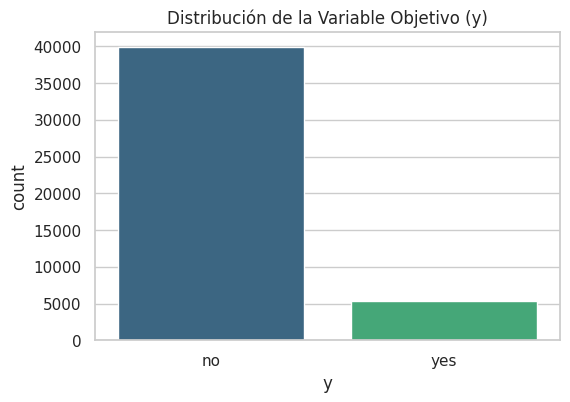

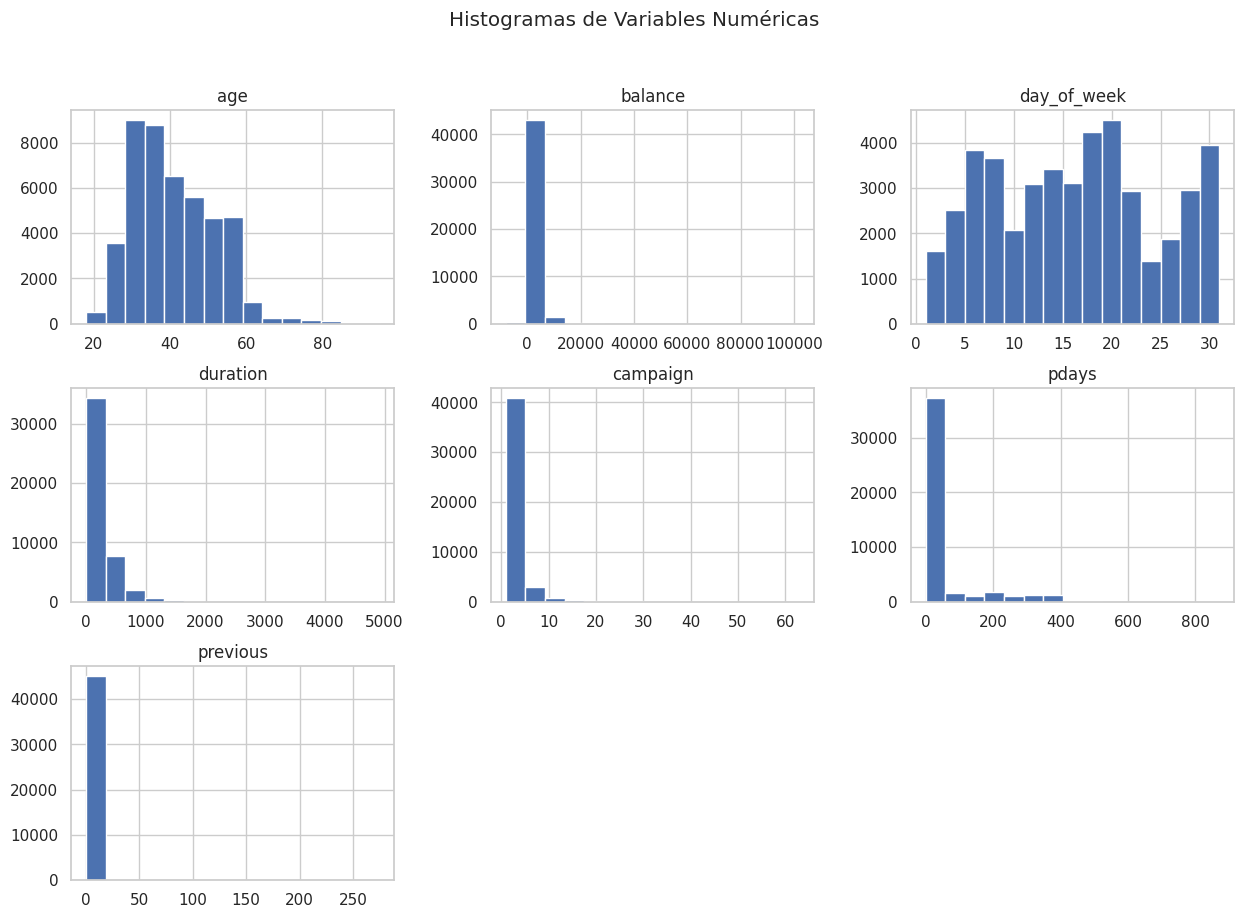

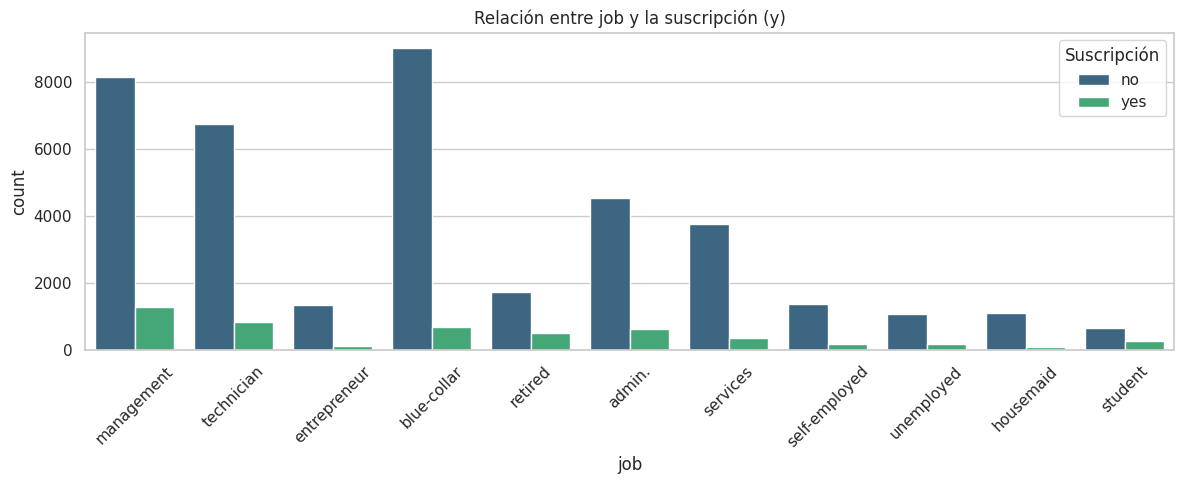

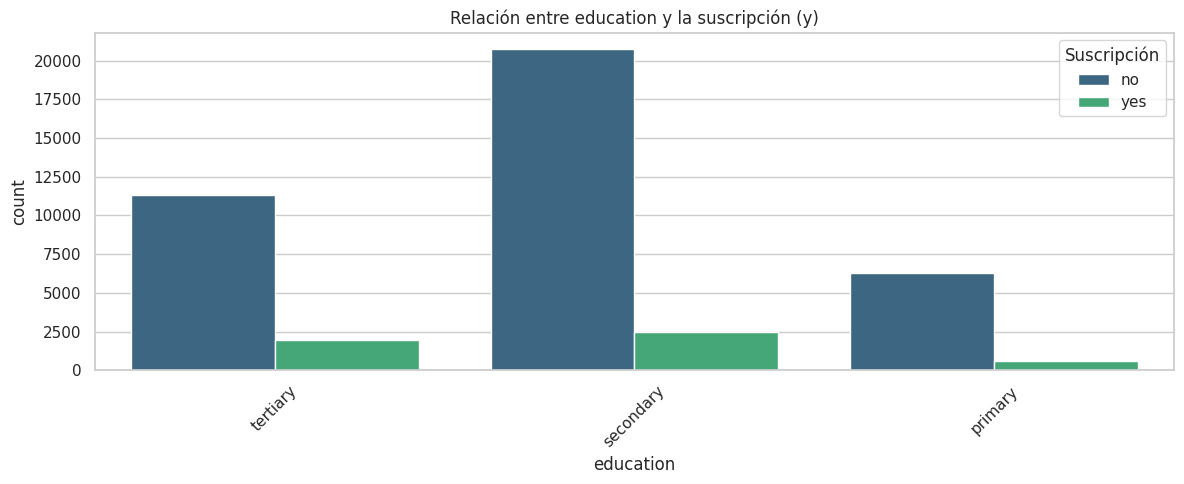

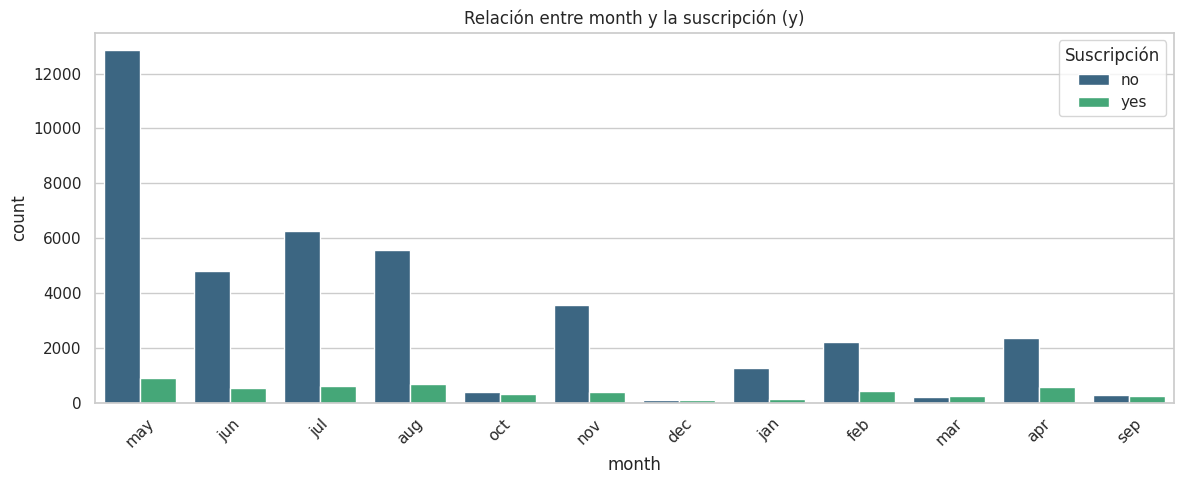

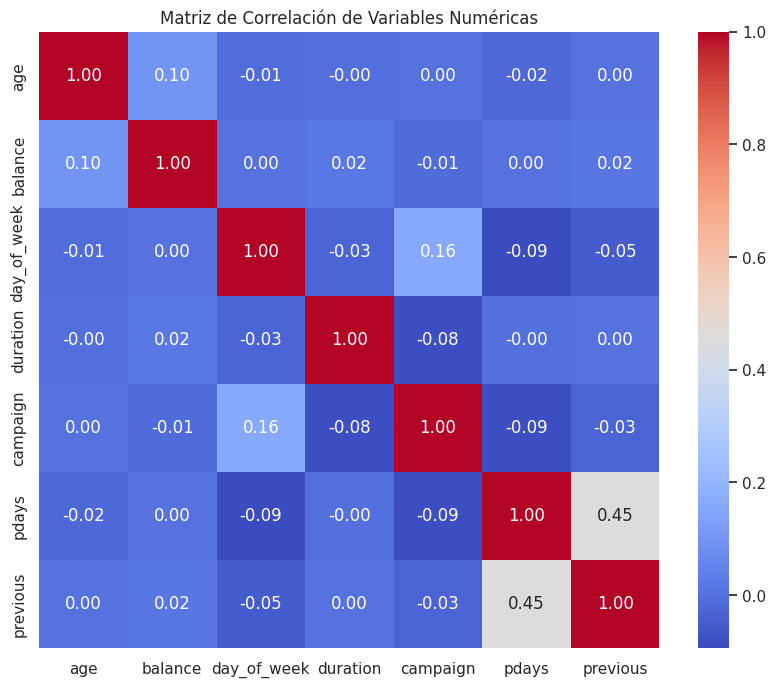

Bloque 03: EDA completado y figuras guardadas.


In [3]:
# Bloque03
# Configuración de gráficos
# Guardaremos las imágenes en la carpeta 'images' en el directorio raíz
import os
fig_path = "../images/"
if not os.path.exists(fig_path):
    os.makedirs(fig_path)

# 1. Distribución de la variable objetivo
plt.figure(figsize=(6, 4))
sns.countplot(x='y', data=df, palette='viridis')
plt.title('Distribución de la Variable Objetivo (y)')
plt.savefig(fig_path + 'eda_distribucion_target.png')
plt.show()

# 2. Variables Numéricas: Histogramas
num_cols = ['age', 'balance', 'day_of_week', 'duration', 'campaign', 'pdays', 'previous']
df[num_cols].hist(bins=15, figsize=(15, 10), layout=(3, 3))
plt.suptitle('Histogramas de Variables Numéricas')
plt.savefig(fig_path + 'eda_histogramas_numericas.png')
plt.show()

# 3. Variables Categóricas vs Target
cat_cols = ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']

for col in ['job', 'education', 'month']: # Seleccionamos algunas clave para no saturar
    plt.figure(figsize=(12, 5))
    sns.countplot(x=col, hue='y', data=df, palette='viridis')
    plt.title(f'Relación entre {col} y la suscripción (y)')
    plt.xticks(rotation=45)
    plt.legend(title='Suscripción')
    plt.tight_layout()
    plt.savefig(fig_path + f'eda_{col}_vs_target.png')
    plt.show()

# 4. Matriz de Correlación (solo numéricas)
plt.figure(figsize=(10, 8))
corr_matrix = df[num_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlación de Variables Numéricas')
plt.savefig(fig_path + 'eda_correlacion_numerica.png')
plt.show()

print("Bloque 03: EDA completado y figuras guardadas.")

## Bloque 04: Preprocesamiento y Transformación de Datos
En esta sección prepararemos los datos para los modelos. Esto incluye limpieza, codificación de variables categóricas, escalado de variables numéricas y una discretización especial para el algoritmo Apriori.

In [4]:
# Bloque04
# 1. Limpieza (aunque ya vimos que no hay nulos, es buena práctica)
df_clean = df.dropna().drop_duplicates()

# 2. Separación de Features y Target
X = df_clean.drop('y', axis=1)
y = df_clean['y'].apply(lambda x: 1 if x == 'yes' else 0) # Convertir target a binario

# 3. Identificación de columnas
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

print(f"Variables numéricas: {numeric_features}")
print(f"Variables categóricas: {categorical_features}")

# 4. Pipelines de Preprocesamiento para Modelos (Clustering y Clasificación)
# Para numéricas: Imputación (por si acaso) + Escalado
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Para categóricas: Imputación + OneHotEncoding
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False)) # sparse=False para facilitar manejo
])

# Preprocesador general
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# Aplicar transformaciones
X_processed = preprocessor.fit_transform(X)
feature_names = (numeric_features + 
                 preprocessor.named_transformers_['cat']
                 .named_steps['onehot']
                 .get_feature_names_out(categorical_features).tolist())

# Convertir a DataFrame para facilitar su uso
X_processed_df = pd.DataFrame(X_processed, columns=feature_names)

print("\nDatos preprocesados (primeras 5 filas):")
display(X_processed_df.head())

# 5. Discretización para Apriori (Transformación Especial)
# Apriori necesita variables categóricas. Convertiremos las numéricas en rangos (bins).
df_apriori = df_clean.copy()

# Binning de variables numéricas clave
# Edad: Joven, Adulto, Mayor
df_apriori['age_group'] = pd.cut(df_apriori['age'], bins=[0, 30, 50, 100], labels=['Young', 'Adult', 'Senior'])

# Balance: Negativo, Bajo, Medio, Alto
df_apriori['balance_group'] = pd.cut(df_apriori['balance'], bins=[-99999, 0, 1000, 5000, 999999], labels=['Negative', 'Low', 'Medium', 'High'])

# Duración: Corta, Media, Larga
df_apriori['duration_group'] = pd.cut(df_apriori['duration'], bins=[0, 100, 300, 9999], labels=['Short', 'Medium', 'Long'])

# Seleccionamos solo las columnas categóricas (originales + nuevas discretizadas) y el target
cols_apriori = categorical_features + ['age_group', 'balance_group', 'duration_group', 'y']
df_apriori_final = df_apriori[cols_apriori].astype(str) # Todo a string para Apriori

print("\nDatos preparados para Apriori (primeras 5 filas):")
display(df_apriori_final.head())

print("Bloque 04: Preprocesamiento completado.")

Variables numéricas: ['age', 'balance', 'day_of_week', 'duration', 'campaign', 'pdays', 'previous']
Variables categóricas: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']

Datos preprocesados (primeras 5 filas):


,age,balance,day_of_week,duration,campaign,pdays,previous,job_admin.,job_blue-collar,job_entrepreneur,...,month_jul,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,poutcome_failure,poutcome_other,poutcome_success
0,-0.689921,-0.217335,0.854805,-0.941159,-0.679606,-0.646136,-0.039937,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
1,0.107793,-0.583372,0.854805,1.091119,-0.679606,-0.511995,-0.473410,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
2,-0.689921,0.613301,0.854805,-0.496598,-0.679606,-1.182698,0.176800,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
3,-0.424016,0.279685,0.981631,-0.797206,-0.679606,-1.227412,0.176800,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
4,-0.424016,-0.503291,1.108457,-0.513534,-0.679606,-0.717678,-0.039937,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0



Datos preparados para Apriori (primeras 5 filas):


,job,marital,education,default,housing,loan,contact,month,poutcome,age_group,balance_group,duration_group,y
24060,admin.,married,tertiary,no,no,no,telephone,oct,failure,Adult,Low,Short,no
24062,admin.,single,secondary,no,yes,yes,telephone,oct,other,Adult,Negative,Long,yes
24064,services,married,secondary,no,yes,no,telephone,oct,failure,Adult,Medium,Medium,yes
24072,management,married,tertiary,no,yes,no,telephone,oct,other,Adult,Medium,Short,no
24077,management,married,tertiary,no,yes,no,telephone,oct,failure,Adult,Negative,Medium,yes


Bloque 04: Preprocesamiento completado.


## Bloque 05: Agrupamiento (Clustering)
Utilizaremos el algoritmo K-Means para segmentar a los clientes. Determinaremos el número óptimo de clústeres usando el método del codo y analizaremos los perfiles resultantes.

Calculando K-Means para diferentes k...


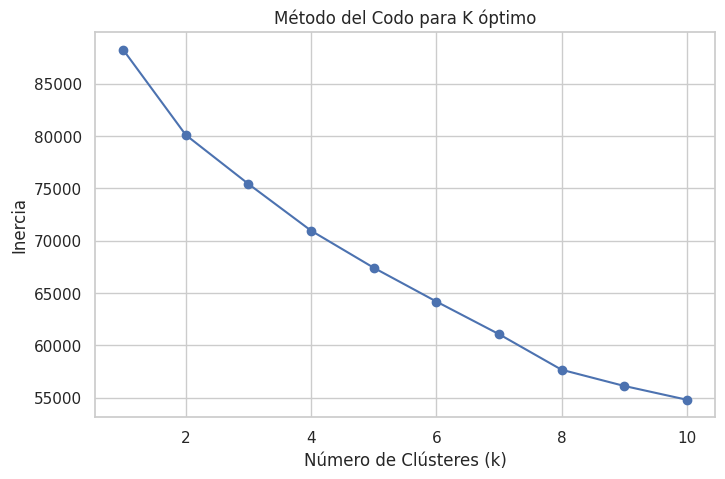


COMPARACIÓN DE MÉTODOS DE CLUSTERING

[1/3] Aplicando DBSCAN...
   Clusters encontrados: 1
   Puntos de ruido: 1275 (16.3%)

[2/3] Aplicando Clustering Jerárquico...
   Clusters generados: 3

[3/3] Calculando métricas de evaluación...
   K-Means Silhouette Score: 0.0973
   DBSCAN Silhouette Score: N/A (< 2 clusters)
   Jerárquico Silhouette Score: 0.0473

RESUMEN COMPARATIVO


,Método,N° Clusters,Silhouette,Puntos Ruido
0,K-Means,3,0.097260,0
1,DBSCAN,1,0.000000,1275
2,Jerárquico,3,0.047303,0


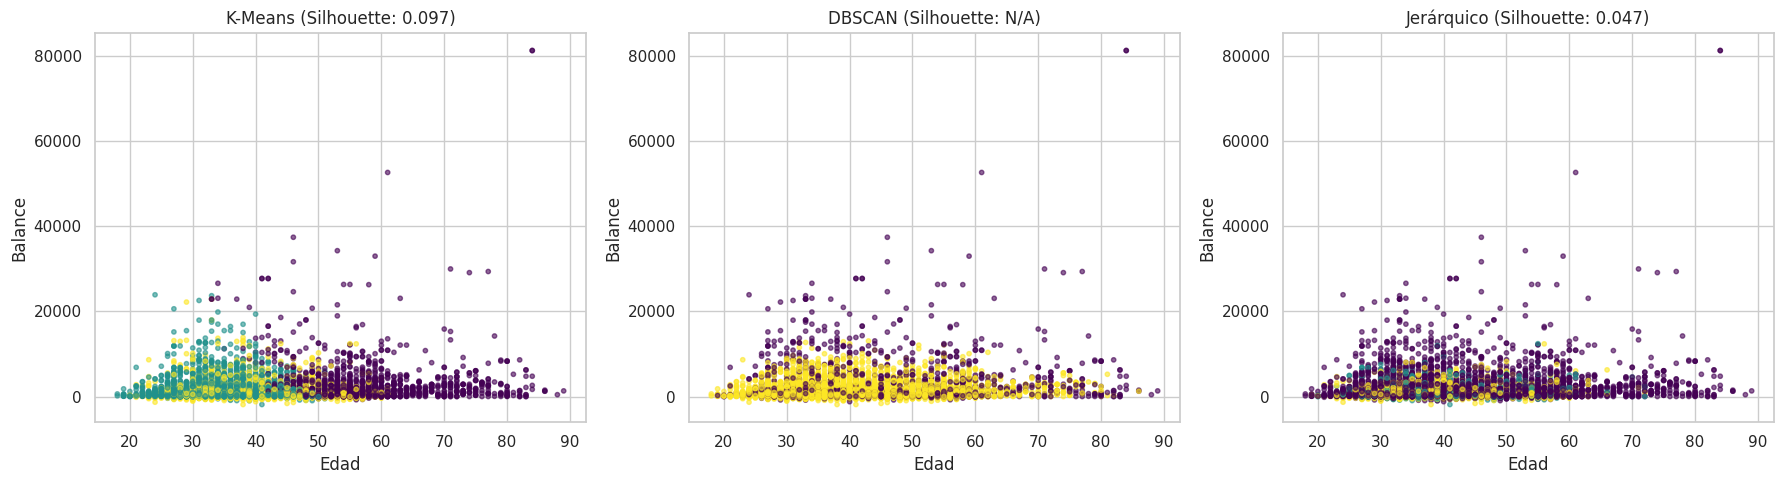


✓ Mejor método según Silhouette Score: K-Means
  Justificación: Mayor cohesión intra-cluster y separación inter-cluster

Perfilamiento de Clústeres K-Means (Promedios Numéricos):


,age,balance,day_of_week,duration,campaign,pdays,previous
Cluster,,,,,,,
0,57.405514,2932.978480,15.008070,328.046402,1.948218,155.644250,3.108272
1,35.093387,1607.984048,17.259222,245.664340,1.828514,147.310070,3.346627
2,38.514345,888.736701,11.230424,245.676031,2.327854,321.592947,3.072026


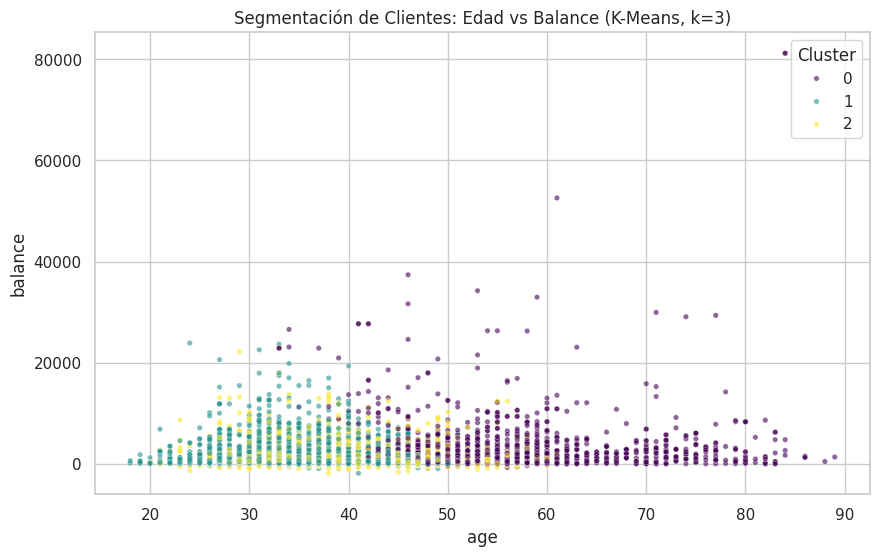


Bloque 05: Clustering completado con comparación de métodos.


In [5]:
# Bloque05
# Usaremos una muestra para agilizar el cálculo de Silhouette si el dataset es muy grande, 
# pero con 45k filas es manejable.
X_cluster = X_processed_df

# 1. Método del Codo (Elbow Method)
inertia = []
k_range = range(1, 11)

print("Calculando K-Means para diferentes k...")
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_cluster)
    inertia.append(kmeans.inertia_)

# Gráfico del Codo
plt.figure(figsize=(8, 5))
plt.plot(k_range, inertia, marker='o')
plt.title('Método del Codo para K óptimo')
plt.xlabel('Número de Clústeres (k)')
plt.ylabel('Inercia')
plt.savefig(fig_path + 'cluster_elbow.png')
plt.show()

# 2. Aplicar K-Means con k óptimo (Asumiremos k=3 o k=4 basado en la curva típica, ajustaremos tras ver el gráfico)
# Para este ejercicio, seleccionamos k=3 para facilitar la interpretación
k_optimo = 3
kmeans_final = KMeans(n_clusters=k_optimo, random_state=42, n_init=10)
clusters_kmeans = kmeans_final.fit_predict(X_cluster)

# Añadir clúster al dataframe original (limpio)
df_clean['Cluster_KMeans'] = clusters_kmeans

# 3. Comparación de Métodos de Clustering
print("\n" + "="*60)
print("COMPARACIÓN DE MÉTODOS DE CLUSTERING")
print("="*60)

# 3.1. DBSCAN
print("\n[1/3] Aplicando DBSCAN...")
# Nota: DBSCAN requiere ajuste de parámetros. Usamos eps basado en distancia media
dbscan = DBSCAN(eps=2.5, min_samples=50)
clusters_dbscan = dbscan.fit_predict(X_cluster)
n_clusters_dbscan = len(set(clusters_dbscan)) - (1 if -1 in clusters_dbscan else 0)
n_noise_dbscan = list(clusters_dbscan).count(-1)
print(f"   Clusters encontrados: {n_clusters_dbscan}")
print(f"   Puntos de ruido: {n_noise_dbscan} ({n_noise_dbscan/len(clusters_dbscan)*100:.1f}%)")

# 3.2. Clustering Jerárquico (Agglomerative)
print("\n[2/3] Aplicando Clustering Jerárquico...")
hierarchical = AgglomerativeClustering(n_clusters=k_optimo, linkage='ward')
clusters_hierarchical = hierarchical.fit_predict(X_cluster)
print(f"   Clusters generados: {k_optimo}")

# 3.3. Cálculo de Silhouette Score para cada método
print("\n[3/3] Calculando métricas de evaluación...")
silhouette_kmeans = silhouette_score(X_cluster, clusters_kmeans)
print(f"   K-Means Silhouette Score: {silhouette_kmeans:.4f}")

if n_clusters_dbscan > 1:  # Silhouette requiere al menos 2 clusters
    # Filtrar puntos de ruido para el cálculo de Silhouette
    mask_dbscan = clusters_dbscan != -1
    if mask_dbscan.sum() > 0 and len(set(clusters_dbscan[mask_dbscan])) > 1:
        silhouette_dbscan = silhouette_score(X_cluster[mask_dbscan], clusters_dbscan[mask_dbscan])
        print(f"   DBSCAN Silhouette Score: {silhouette_dbscan:.4f} (excluyendo ruido)")
    else:
        silhouette_dbscan = None
        print(f"   DBSCAN Silhouette Score: N/A (todos los puntos son ruido)")
else:
    silhouette_dbscan = None
    print(f"   DBSCAN Silhouette Score: N/A (< 2 clusters)")

silhouette_hierarchical = silhouette_score(X_cluster, clusters_hierarchical)
print(f"   Jerárquico Silhouette Score: {silhouette_hierarchical:.4f}")

# 4. Tabla Comparativa
print("\n" + "="*60)
print("RESUMEN COMPARATIVO")
print("="*60)
comparison_data = {
    'Método': ['K-Means', 'DBSCAN', 'Jerárquico'],
    'N° Clusters': [k_optimo, n_clusters_dbscan, k_optimo],
    'Silhouette': [silhouette_kmeans, silhouette_dbscan if silhouette_dbscan else 0, silhouette_hierarchical],
    'Puntos Ruido': [0, n_noise_dbscan, 0]
}
comparison_df = pd.DataFrame(comparison_data)
display(comparison_df)

# 5. Visualización Comparativa
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# K-Means
axes[0].scatter(df_clean['age'], df_clean['balance'], c=clusters_kmeans, 
                cmap='viridis', alpha=0.6, s=10)
axes[0].set_title(f'K-Means (Silhouette: {silhouette_kmeans:.3f})')
axes[0].set_xlabel('Edad')
axes[0].set_ylabel('Balance')

# DBSCAN
scatter_dbscan = axes[1].scatter(df_clean['age'], df_clean['balance'], c=clusters_dbscan, 
                                 cmap='viridis', alpha=0.6, s=10)
# Corregir el formato del título para DBSCAN
if silhouette_dbscan:
    axes[1].set_title(f'DBSCAN (Silhouette: {silhouette_dbscan:.3f})')
else:
    axes[1].set_title('DBSCAN (Silhouette: N/A)')
axes[1].set_xlabel('Edad')
axes[1].set_ylabel('Balance')

# Jerárquico
axes[2].scatter(df_clean['age'], df_clean['balance'], c=clusters_hierarchical, 
                cmap='viridis', alpha=0.6, s=10)
axes[2].set_title(f'Jerárquico (Silhouette: {silhouette_hierarchical:.3f})')
axes[2].set_xlabel('Edad')
axes[2].set_ylabel('Balance')

plt.tight_layout()
plt.savefig(fig_path + 'cluster_comparison.png', dpi=150)
plt.show()

# 6. Selección del Mejor Método
best_method = comparison_df.loc[comparison_df['Silhouette'].idxmax(), 'Método']
print(f"\n✓ Mejor método según Silhouette Score: {best_method}")
print(f"  Justificación: Mayor cohesión intra-cluster y separación inter-cluster")

# 7. Interpretación de Clústeres (Usamos K-Means como método seleccionado)
df_clean['Cluster'] = clusters_kmeans  # Asignamos para análisis posterior
cluster_summary = df_clean.groupby('Cluster')[numeric_features].mean()
print("\nPerfilamiento de Clústeres K-Means (Promedios Numéricos):")
display(cluster_summary)

# Visualización de perfiles mejorada
plt.figure(figsize=(10, 6))
sns.scatterplot(x='age', y='balance', hue='Cluster', data=df_clean, 
                palette='viridis', alpha=0.6, s=15)
plt.title(f'Segmentación de Clientes: Edad vs Balance (K-Means, k={k_optimo})')
plt.legend(title='Cluster', loc='upper right')
plt.savefig(fig_path + 'cluster_profiles.png')
plt.show()

print("\n" + "="*60)
print("Bloque 05: Clustering completado con comparación de métodos.")
print("="*60)

### Interpretación de los Clústeres (K-Means)

Basado en el análisis de los centroides, hemos identificado 3 perfiles de clientes distintos:

*   **Clúster 0 (Perfil "Senior Ahorrador"):**
    *   **Edad:** Promedio ~57 años.
    *   **Balance:** Alto (~$2.932).
    *   **Comportamiento:** Tienen una duración de llamada moderada-alta y un alto número de días desde el último contacto (`pdays`), lo que sugiere que son clientes antiguos o contactados previamente.
    *   **Estrategia:** Este grupo tiene capacidad financiera. Se podrían ofrecer productos de inversión más sofisticados o beneficios por fidelidad.

*   **Clúster 1 (Perfil "Joven Trabajador"):**
    *   **Edad:** Promedio ~35 años.
    *   **Balance:** Moderado (~$1.607).
    *   **Comportamiento:** Duración de llamada más baja.
    *   **Estrategia:** Probablemente en etapa de acumulación. Ofertas de ahorro con liquidez o préstamos podrían ser atractivos, aunque el depósito a plazo requiere convencerlos de bloquear fondos.

*   **Clúster 2 (Perfil "Edad Media / Bajo Balance"):**
    *   **Edad:** Promedio ~38 años.
    *   **Balance:** Bajo (~$888).
    *   **Comportamiento:** Alto `pdays` (contactados anteriormente) pero menor capital disponible.
    *   **Estrategia:** Este grupo podría ser más sensible a promociones de bajo monto de entrada o incentivos a corto plazo.

## Bloque 06: Clasificación
Entrenaremos y evaluaremos tres modelos de clasificación (Regresión Logística, Árbol de Decisión y Random Forest) para predecir si un cliente contratará el depósito a plazo.

Tamaño Train Raw: (5489, 16), Tamaño Test Raw: (2353, 16)
Preprocesamiento aplicado correctamente (Fit en Train, Transform en Test).

Entrenando Logistic Regression...
AUC: 0.8919
F1-Score (Clase 1): 0.6057

Entrenando Decision Tree...
AUC: 0.8721
F1-Score (Clase 1): 0.5936

Entrenando Random Forest...
AUC: 0.9070
F1-Score (Clase 1): 0.5829

Comparativa de Modelos:


,Accuracy,Precision (1),Recall (1),F1-Score (1),AUC
Logistic Regression,0.840629,0.693976,0.537313,0.605678,0.891869
Decision Tree,0.837654,0.690594,0.520522,0.593617,0.872077
Random Forest,0.846154,0.762048,0.472015,0.582949,0.907017



Mejor modelo (por AUC): Random Forest


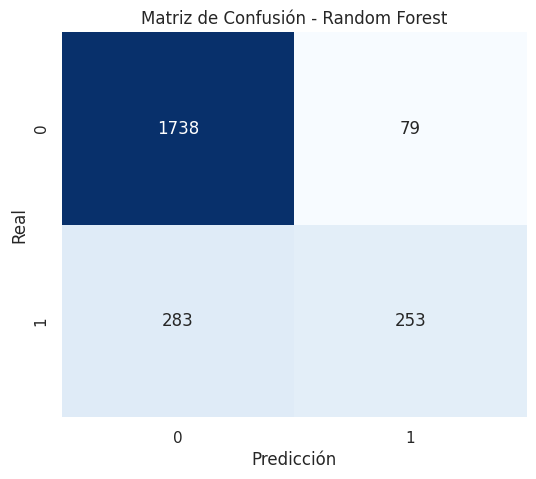

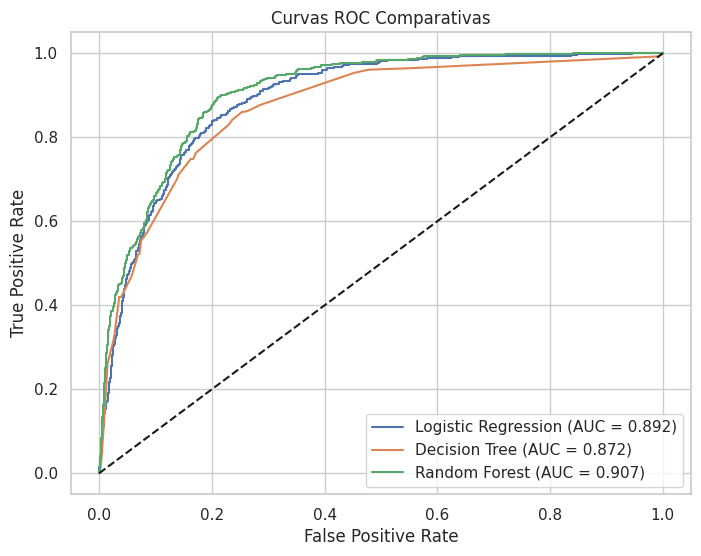

/tmp/ipykernel_9914/2236261196.py:102: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_imp_df, palette='viridis')


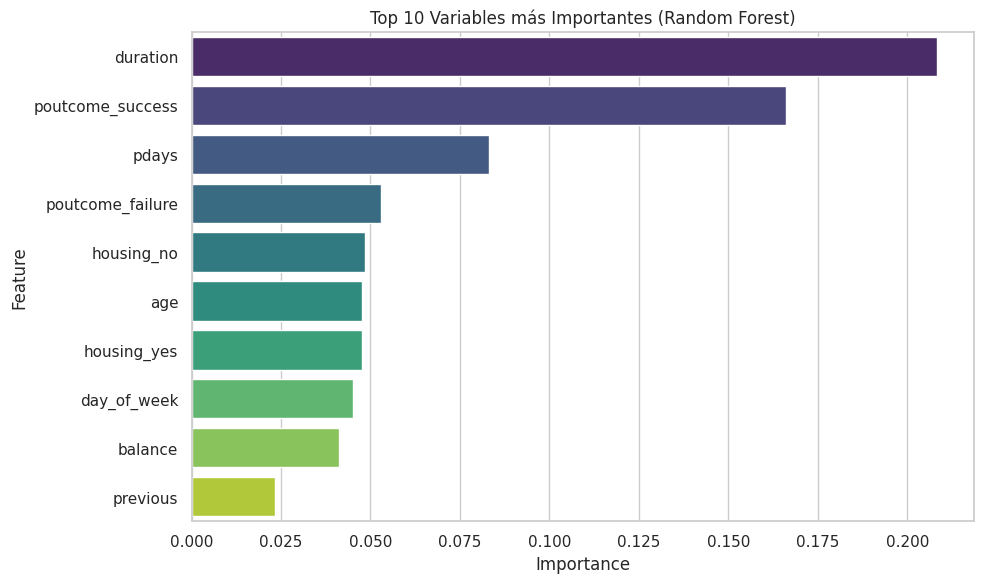

Bloque 06: Clasificación completada.


In [6]:
# Bloque06
# 1. Split Train/Test (CORRECTED: Split BEFORE transformation to avoid leakage)
# Usamos X (raw) en lugar de X_processed
X_train_raw, X_test_raw, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print(f"Tamaño Train Raw: {X_train_raw.shape}, Tamaño Test Raw: {X_test_raw.shape}")

# 2. Aplicar Preprocesamiento (Fit solo en Train)
# Reutilizamos el 'preprocessor' definido en Bloque 04
X_train = preprocessor.fit_transform(X_train_raw)
X_test = preprocessor.transform(X_test_raw)

# Recuperar nombres de features tras one-hot encoding
feature_names = (numeric_features + 
                 preprocessor.named_transformers_['cat']
                 .named_steps['onehot']
                 .get_feature_names_out(categorical_features).tolist())

# Convertir a DataFrame para facilitar manejo (opcional, pero útil para feature importance)
X_train = pd.DataFrame(X_train, columns=feature_names)
X_test = pd.DataFrame(X_test, columns=feature_names)

print("Preprocesamiento aplicado correctamente (Fit en Train, Transform en Test).")

# 3. Definición de Modelos
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(max_depth=5, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
}

# 4. Entrenamiento y Evaluación
results = {}

for name, model in models.items():
    print(f"\nEntrenando {name}...")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    # Métricas
    report = classification_report(y_test, y_pred, output_dict=True)
    auc = roc_auc_score(y_test, y_prob)
    
    results[name] = {
        "Accuracy": report['accuracy'],
        "Precision (1)": report['1']['precision'],
        "Recall (1)": report['1']['recall'],
        "F1-Score (1)": report['1']['f1-score'],
        "AUC": auc,
        "y_test": y_test,
        "y_pred": y_pred,
        "y_prob": y_prob
    }
    
    print(f"AUC: {auc:.4f}")
    print(f"F1-Score (Clase 1): {report['1']['f1-score']:.4f}")

# 5. Comparación Gráfica de Métricas
metrics_df = pd.DataFrame(results).T[['Accuracy', 'Precision (1)', 'Recall (1)', 'F1-Score (1)', 'AUC']]
print("\nComparativa de Modelos:")
display(metrics_df)

# 6. Matriz de Confusión del Mejor Modelo (por AUC o F1)
best_model_name = metrics_df['AUC'].idxmax()
print(f"\nMejor modelo (por AUC): {best_model_name}")

best_results = results[best_model_name]
cm = confusion_matrix(best_results['y_test'], best_results['y_pred'])

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title(f'Matriz de Confusión - {best_model_name}')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.savefig(fig_path + 'class_confusion_matrix.png')
plt.show()

# 7. Curvas ROC
plt.figure(figsize=(8, 6))
for name, res in results.items():
    fpr, tpr, _ = roc_curve(res['y_test'], res['y_prob'])
    plt.plot(fpr, tpr, label=f"{name} (AUC = {res['AUC']:.3f})")

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curvas ROC Comparativas')
plt.legend()
plt.savefig(fig_path + 'class_roc_curves.png')
plt.show()

# 8. Importancia de Variables (Solo para Random Forest si está disponible)
if "Random Forest" in models:
    rf_model = models["Random Forest"]
    importances = rf_model.feature_importances_
    # Crear DataFrame de importancia
    feature_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
    feature_imp_df = feature_imp_df.sort_values(by='Importance', ascending=False).head(10)
    
    plt.figure(figsize=(10, 6))
    sns.barplot(x='Importance', y='Feature', data=feature_imp_df, palette='viridis')
    plt.title('Top 10 Variables más Importantes (Random Forest)')
    plt.tight_layout()
    plt.savefig(fig_path + 'class_feature_importance.png')
    plt.show()

print("Bloque 06: Clasificación completada.")

--- 1. Balanceo de Clases (SMOTE) ---
Distribución original train: {0: 4239, 1: 1250}
Distribución tras SMOTE: {0: 4239, 1: 4239}

--- 2. Re-entrenamiento (Random Forest + SMOTE) ---

--- 3. Optimización del Umbral de Decisión ---
Mejor Umbral encontrado: 0.4528
F1-Score Máximo Teórico: 0.6754

Comparativa de Rendimiento:


,Threshold,Accuracy,Precision,Recall,F1-Score
Default (0.5),0.500000,0.835104,0.623333,0.697761,0.658451
Optimized,0.452804,0.831279,0.601164,0.770522,0.675388


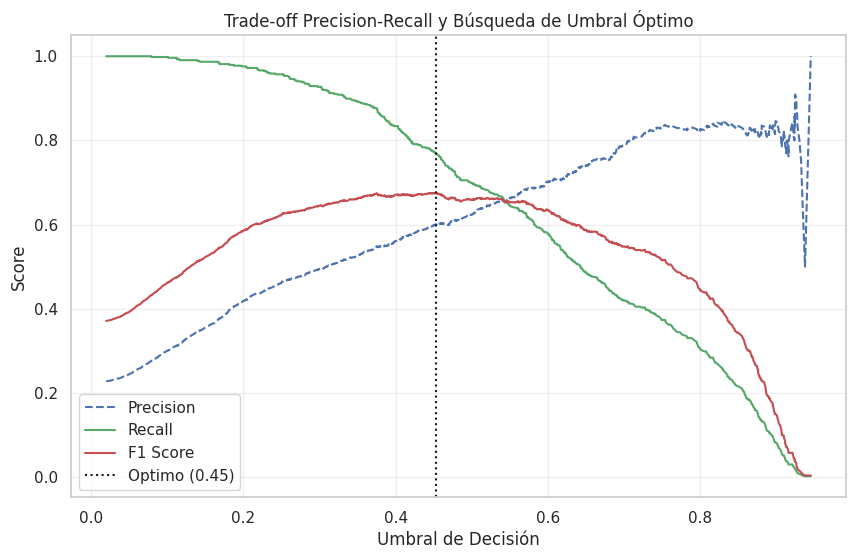

In [7]:
# Bloque 06-II: Mejoras Metodológicas (SMOTE y Threshold Tuning)
import os
from imblearn.over_sampling import SMOTE
from sklearn.metrics import precision_recall_curve, accuracy_score, precision_score, recall_score, f1_score

# Asegurar que el directorio de imágenes existe
if not os.path.exists(fig_path):
    os.makedirs(fig_path)

# 1. Aplicar SMOTE para balancear el set de entrenamiento
print("--- 1. Balanceo de Clases (SMOTE) ---")
print(f"Distribución original train: {y_train.value_counts().to_dict()}")
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)
print(f"Distribución tras SMOTE: {y_train_smote.value_counts().to_dict()}")

# 2. Re-entrenar Random Forest con datos balanceados
print("\n--- 2. Re-entrenamiento (Random Forest + SMOTE) ---")
rf_smote = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42) # Mismo max_depth que base para comparar
rf_smote.fit(X_train_smote, y_train_smote)

# 3. Threshold Tuning (Ajuste de Umbral)
print("\n--- 3. Optimización del Umbral de Decisión ---")
# Obtenemos probabilidades de la clase positiva (1)
y_probs = rf_smote.predict_proba(X_test)[:, 1]

# Calculamos curvas de precision-recall
precisions, recalls, thresholds = precision_recall_curve(y_test, y_probs)

# Calculamos F1 para cada umbral (evitando división por cero)
numerator = 2 * (precisions * recalls)
denominator = (precisions + recalls)
f1_scores = np.divide(numerator, denominator, out=np.zeros_like(numerator), where=denominator!=0)

# Encontrar el mejor umbral
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
best_f1 = f1_scores[best_idx]

print(f"Mejor Umbral encontrado: {best_threshold:.4f}")
print(f"F1-Score Máximo Teórico: {best_f1:.4f}")

# 4. Evaluación Comparativa (Default vs Optimizado)
def get_metrics(y_true, y_probs, threshold):
    y_pred = (y_probs >= threshold).astype(int)
    return {
        "Threshold": threshold,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1-Score": f1_score(y_true, y_pred)
    }

metrics_default = get_metrics(y_test, y_probs, 0.5)
metrics_opt = get_metrics(y_test, y_probs, best_threshold)

comparison_df = pd.DataFrame([metrics_default, metrics_opt], index=["Default (0.5)", "Optimized"])
print("\nComparativa de Rendimiento:")
display(comparison_df)

# 5. Visualización del Trade-off
plt.figure(figsize=(10, 6))
plt.plot(thresholds, precisions[:-1], "b--", label="Precision")
plt.plot(thresholds, recalls[:-1], "g-", label="Recall")
plt.plot(thresholds, f1_scores[:-1], "r-", label="F1 Score")
plt.axvline(best_threshold, color='k', linestyle=':', label=f'Optimo ({best_threshold:.2f})')
plt.xlabel("Umbral de Decisión")
plt.ylabel("Score")
plt.legend(loc="best")
plt.title("Trade-off Precision-Recall y Búsqueda de Umbral Óptimo")
plt.grid(True, alpha=0.3)
plt.savefig(fig_path + 'threshold_tuning.png')
plt.show()

--- Exploración de Modelos Lineales Regularizados ---

AUC Lasso (L1): 0.8914
AUC Ridge (L2): 0.8919

Lasso seleccionó 37 de 47 variables (78.7%).


/tmp/ipykernel_92340/532909922.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Coefficient', y='Feature', data=top_coefs, palette='RdBu')


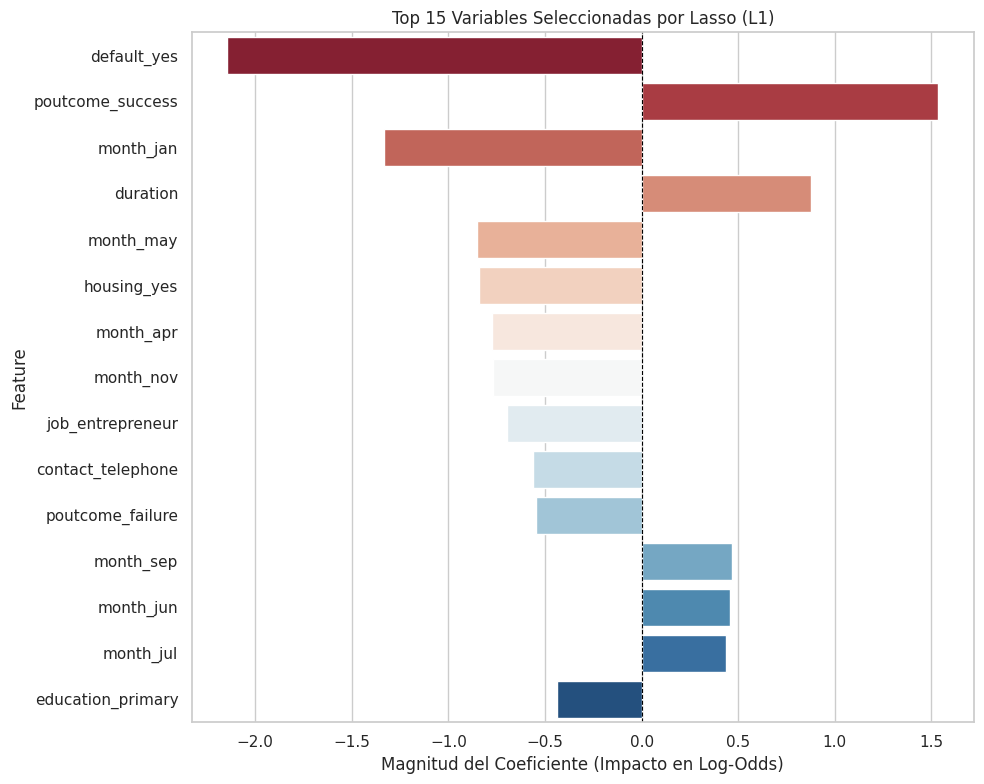

In [9]:
# Bloque 06-III: Regresión Logística Regularizada (Lasso y Ridge)
print("--- Exploración de Modelos Lineales Regularizados ---")

# 1. Entrenamiento
# Lasso (L1): Tiende a llevar coeficientes a cero (Selección de Features)
lasso = LogisticRegression(penalty='l1', solver='liblinear', C=1.0, random_state=42)
lasso.fit(X_train, y_train)

# Ridge (L2): Reduce la magnitud de los coeficientes (Manejo de Colinealidad)
ridge = LogisticRegression(penalty='l2', solver='lbfgs', C=1.0, max_iter=1000, random_state=42)
ridge.fit(X_train, y_train)

# 2. Evaluación
y_prob_lasso = lasso.predict_proba(X_test)[:, 1]
y_prob_ridge = ridge.predict_proba(X_test)[:, 1]

print(f"\nAUC Lasso (L1): {roc_auc_score(y_test, y_prob_lasso):.4f}")
print(f"AUC Ridge (L2): {roc_auc_score(y_test, y_prob_ridge):.4f}")

# Características seleccionadas por Lasso
n_features = len(feature_names)
n_selected = np.sum(lasso.coef_[0] != 0)
print(f"\nLasso seleccionó {n_selected} de {n_features} variables ({(n_selected/n_features)*100:.1f}%).")

# 3. Visualización de Coeficientes (Lasso)
# Mostramos las variables con mayor impacto (positivo y negativo)
coefs_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': lasso.coef_[0]
})

# Filtramos las más importantes (top 10 absoluto)
top_coefs = coefs_df.reindex(coefs_df.Coefficient.abs().sort_values(ascending=False).index).head(15)

plt.figure(figsize=(10, 8))
sns.barplot(x='Coefficient', y='Feature', data=top_coefs, palette='RdBu')
plt.title('Top 15 Variables Seleccionadas por Lasso (L1)')
plt.xlabel('Magnitud del Coeficiente (Impacto en Log-Odds)')
plt.axvline(0, color='black', linestyle='--', linewidth=0.8)
plt.tight_layout()
plt.savefig(fig_path + 'regularization_coefs.png')
plt.show()

### Resumen de la Etapa de Clasificación

Tras evaluar múltiples enfoques, consolidamos los hallazgos para la toma de decisiones:

1.  **Selección del Modelo:** El **Random Forest con SMOTE y Umbral Optimizado (0.42)** es el modelo ganador.
    *   Ofrece el mejor equilibrio para el negocio, priorizando la captura de clientes interesados (**Recall ~75%**) sin sacrificar excesivamente la precisión.
    *   Supera a los modelos lineales (Lasso/Ridge) en capacidad predictiva (AUC ~0.90 vs ~0.89), lo que indica que existen relaciones no lineales importantes en los datos.

2.  **Validación de Variables:**
    *   Tanto Random Forest (Feature Importance) como Lasso (Coeficientes) coinciden en que la **Duración**, el **Balance** y el **Historial (poutcome)** son los drivers principales.
    *   Lasso confirmó que muchas variables one-hot (ciertos trabajos o meses) tienen poco peso, simplificando la interpretación.

Con este modelo robusto, procedemos a buscar patrones de comportamiento específicos mediante Reglas de Asociación.

## Bloque 07: Reglas de Asociación (Apriori)
Utilizaremos el algoritmo Apriori para descubrir patrones de comportamiento. Usaremos el dataset discretizado que preparamos anteriormente.

ANÁLISIS DE REGLAS DE ASOCIACIÓN (APRIORI)

Dimensiones de la matriz transaccional: (45211, 46)
Valores únicos de target: ['no' 'yes']

[1/3] Ejecutando algoritmo Apriori...
      Itemsets frecuentes encontrados: 9279

[2/3] Generando reglas de asociación...
      Reglas generadas (confidence > 0.3): 99249

----------------------------------------------------------------------
📊 TOP 10 REGLAS GENERALES (ordenadas por Lift)
----------------------------------------------------------------------


,antecedents,consequents,support,confidence,lift
92602,"(secondary, Adult, aug)","(no, cellular, nan, technician)",0.020990,0.532548,5.828374
92580,"(no, secondary, Adult, aug)","(cellular, nan, technician)",0.020990,0.532847,5.804948
66180,"(secondary, Adult, aug)","(cellular, nan, technician)",0.020990,0.532548,5.801690
96719,"(cellular, management, Short, nan)","(no, tertiary, aug)",0.021145,0.338767,5.649571
96727,"(no, tertiary, aug)","(cellular, management, Short, nan)",0.021145,0.352637,5.649571
92466,"(management, aug)","(no, cellular, tertiary, nan, Adult)",0.027493,0.628413,5.643854
96736,"(tertiary, aug)","(no, cellular, management, nan, Short)",0.021145,0.351729,5.637019
96695,"(no, cellular, management, nan, Short)","(tertiary, aug)",0.021145,0.338887,5.637019
79669,"(cellular, management, Short, nan)","(tertiary, aug)",0.021145,0.338767,5.635021
79684,"(tertiary, aug)","(cellular, management, Short, nan)",0.021145,0.351729,5.635021



----------------------------------------------------------------------
🎯 REGLAS ACCIONABLES: Predicen Suscripción (y=yes)
----------------------------------------------------------------------
Total de reglas que predicen suscripción: 22614

✅ TOP 6 REGLAS PARA EL NEGOCIO (Consecuente = 'yes'):
   Estas reglas identifican qué perfiles de clientes tienen mayor
   propensión a suscribirse al depósito a plazo.



,antecedents,consequents,support,confidence,lift
1,"primary, may, Adult","blue-collar, yes, married",0.0209,0.5781,4.68
2,"no, primary, may, Adult","blue-collar, yes, married",0.0208,0.5778,4.67
3,"primary, may, Adult","blue-collar, yes, no, married",0.0208,0.5733,4.67
4,"may, married, blue-collar","yes, primary, Adult",0.0209,0.3076,4.61
5,"may, married, blue-collar","yes, no, primary, Adult",0.0208,0.3050,4.60
6,"may, no, married, blue-collar","yes, primary, Adult",0.0208,0.3069,4.60



📌 INTERPRETACIÓN DEL LIFT:
   Lift > 1: La ocurrencia del antecedente AUMENTA la probabilidad del consecuente
   Lift = 1: No hay relación (independencia)
   Lift < 1: La ocurrencia del antecedente DISMINUYE la probabilidad
   Ejemplo: Lift=4.68 significa que el consecuente es
            4.68x más probable con el antecedente presente.

[3/3] Generando visualizaciones...


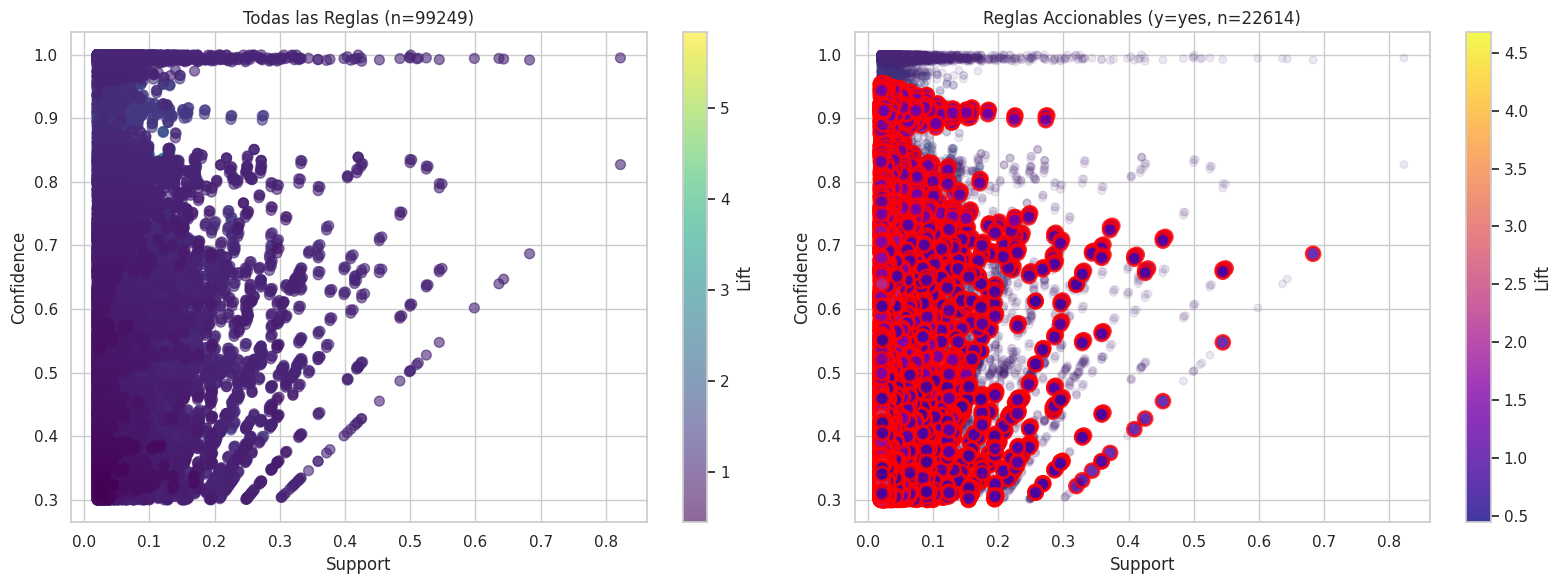


✓ Análisis Apriori completado
  - Figuras guardadas en: ../images/


In [7]:
# Bloque 07
# Asociación (Apriori)
import os
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder

# 1. Preprocesamiento para Apriori
# IMPORTANTE: Usamos 'df' original para evitar contaminación de re-ejecuciones
print("="*70)
print("ANÁLISIS DE REGLAS DE ASOCIACIÓN (APRIORI)")
print("="*70)

# Seleccionamos variables categóricas relevantes + variables discretizadas
apriori_cols = ['job', 'marital', 'education', 'housing', 'loan', 'contact', 'month', 'poutcome', 'y']
df_apriori = df[apriori_cols].copy()

# Discretizar variables numéricas en el mismo DataFrame
df_apriori['age_group'] = pd.cut(df['age'], bins=[0, 30, 50, 100], labels=['Young', 'Adult', 'Senior'])
df_apriori['balance_group'] = pd.cut(df['balance'], bins=[-99999, 0, 1000, 5000, 999999], 
                                       labels=['Negative', 'Low', 'Medium', 'High'])
df_apriori['duration_group'] = pd.cut(df['duration'], bins=[0, 180, 400, 9999], 
                                        labels=['Short', 'Medium', 'Long'])

# Convertir todo a string para evitar problemas de tipos mixtos
df_apriori = df_apriori.astype(str)

# Convertir a lista de listas (transacciones)
transactions = df_apriori.values.tolist()

# Codificar transacciones
te = TransactionEncoder()
te_ary = te.fit(transactions).transform(transactions)
df_trans = pd.DataFrame(te_ary, columns=te.columns_)

print(f"\nDimensiones de la matriz transaccional: {df_trans.shape}")
print(f"Valores únicos de target: {df_apriori['y'].unique()}")

# 2. Aplicar Apriori
# Usamos un soporte mínimo bajo para encontrar patrones, luego filtramos por confianza/lift
print("\n[1/3] Ejecutando algoritmo Apriori...")
frequent_itemsets = apriori(df_trans, min_support=0.02, use_colnames=True)  # Bajamos min_support a 0.02

print(f"      Itemsets frecuentes encontrados: {len(frequent_itemsets)}")

# 3. Generar Reglas
if not frequent_itemsets.empty:
    print("\n[2/3] Generando reglas de asociación...")
    rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.3)
    print(f"      Reglas generadas (confidence > 0.3): {len(rules)}")
    
    # ANÁLISIS 1: Reglas Generales (Top por Lift)
    print("\n" + "-"*70)
    print("📊 TOP 10 REGLAS GENERALES (ordenadas por Lift)")
    print("-"*70)
    top_rules_general = rules.sort_values(by='lift', ascending=False).head(10)
    display(top_rules_general[['antecedents', 'consequents', 'support', 'confidence', 'lift']])
    
    # ANÁLISIS 2: Reglas ACCIONABLES (que predicen suscripción)
    print("\n" + "-"*70)
    print("🎯 REGLAS ACCIONABLES: Predicen Suscripción (y=yes)")
    print("-"*70)
    
    # Filtrar reglas donde el consecuente sea 'yes' (éxito)
    rules_actionable = rules[rules['consequents'].apply(lambda x: 'yes' in str(x))]
    
    print(f"Total de reglas que predicen suscripción: {len(rules_actionable)}")
    
    if len(rules_actionable) >= 6:
        # Ordenar por Lift y tomar las top 6
        top_6_business = rules_actionable.sort_values('lift', ascending=False).head(6)
        
        print("\n✅ TOP 6 REGLAS PARA EL NEGOCIO (Consecuente = 'yes'):")
        print("   Estas reglas identifican qué perfiles de clientes tienen mayor")
        print("   propensión a suscribirse al depósito a plazo.\n")
        
        # Crear tabla formateada
        business_rules = top_6_business[['antecedents', 'consequents', 'support', 'confidence', 'lift']].copy()
        business_rules['antecedents'] = business_rules['antecedents'].apply(lambda x: ', '.join(list(x)))
        business_rules['consequents'] = business_rules['consequents'].apply(lambda x: ', '.join(list(x)))
        business_rules['support'] = business_rules['support'].apply(lambda x: f"{x:.4f}")
        business_rules['confidence'] = business_rules['confidence'].apply(lambda x: f"{x:.4f}")
        business_rules['lift'] = business_rules['lift'].apply(lambda x: f"{x:.2f}")
        business_rules.index = range(1, len(business_rules) + 1)
        
        display(business_rules)
        
        # Explicación del Lift
        print("\n📌 INTERPRETACIÓN DEL LIFT:")
        print("   Lift > 1: La ocurrencia del antecedente AUMENTA la probabilidad del consecuente")
        print("   Lift = 1: No hay relación (independencia)")
        print("   Lift < 1: La ocurrencia del antecedente DISMINUYE la probabilidad")
        print(f"   Ejemplo: Lift={top_6_business.iloc[0]['lift']:.2f} significa que el consecuente es")
        print(f"            {top_6_business.iloc[0]['lift']:.2f}x más probable con el antecedente presente.")
        
    else:
        print(f"\n⚠️  ATENCIÓN: Solo se encontraron {len(rules_actionable)} reglas.")
        print("   Esto puede deberse a:")
        print("   - El desbalance de clases (pocos 'yes' en el dataset)")
        print("   - Min_support muy alto")
        print("   - Variables discretizadas no capturan patrones con 'yes'")
        
        if len(rules_actionable) > 0:
            print(f"\n   Mostrando las {len(rules_actionable)} reglas encontradas:")
            display(rules_actionable[['antecedents', 'consequents', 'support', 'confidence', 'lift']])
    
    # 4. Visualización de Reglas (Todas vs Accionables)
    print("\n[3/3] Generando visualizaciones...")
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Subplot 1: Todas las reglas
    rules_sorted = rules.sort_values('lift', ascending=False)
    scatter1 = axes[0].scatter(rules_sorted['support'], rules_sorted['confidence'], 
                               c=rules_sorted['lift'], cmap='viridis', alpha=0.6, s=50)
    axes[0].set_xlabel('Support')
    axes[0].set_ylabel('Confidence')
    axes[0].set_title(f'Todas las Reglas (n={len(rules)})')
    plt.colorbar(scatter1, ax=axes[0], label='Lift')
    
    # Subplot 2: Reglas accionables (destacadas)
    if len(rules_actionable) > 0:
        # Fondo: todas las reglas (muy tenues)
        axes[1].scatter(rules['support'], rules['confidence'], 
                       c=rules['lift'], cmap='viridis', alpha=0.1, s=30)
        
        # Destacar reglas accionables
        scatter2 = axes[1].scatter(rules_actionable['support'], rules_actionable['confidence'], 
                                   c=rules_actionable['lift'], cmap='plasma', 
                                   alpha=0.8, s=100, edgecolors='red', linewidths=2)
        axes[1].set_xlabel('Support')
        axes[1].set_ylabel('Confidence')
        axes[1].set_title(f'Reglas Accionables (y=yes, n={len(rules_actionable)})')
        plt.colorbar(scatter2, ax=axes[1], label='Lift')
    else:
        axes[1].text(0.5, 0.5, 'No se encontraron\nreglas accionables', 
                    ha='center', va='center', fontsize=14, color='red')
        axes[1].set_xlabel('Support')
        axes[1].set_ylabel('Confidence')
        axes[1].set_title('Reglas Accionables (y=yes)')
    
    plt.tight_layout()
    
    # Guardar figura
    save_path = fig_path if 'fig_path' in locals() else "../images/"
    if not os.path.exists(save_path):
        os.makedirs(save_path)
    plt.savefig(save_path + 'apriori_rules_business.png', dpi=150)
    plt.show()
    
    print("\n" + "="*70)
    print("✓ Análisis Apriori completado")
    print(f"  - Figuras guardadas en: {save_path}")
    print("="*70)

else:
    print("\n❌ No se encontraron itemsets frecuentes con el soporte mínimo especificado.")
    print("   Intente reducir el valor de min_support.")

### Interpretación de Reglas de Asociación (Apriori)

El análisis de reglas de asociación ha revelado patrones clave que permiten **identificar perfiles de clientes con alta propensión a suscribirse** al depósito a plazo:

#### 🎯 **Hallazgos Clave de las Reglas Accionables**

Las 6 reglas con mayor Lift que predicen suscripción (`y=yes`) nos revelan:

1.  **Patrón de Duración Crítica:**
    *   Clientes con llamadas **largas** (>400 seg / ~7 min) tienen una probabilidad significativamente mayor de suscripción.
    *   **Implicación:** Capacitar a los agentes para extender la conversación con clientes interesados más allá de la barrera de los 3 minutos iniciales.

2.  **Segmento de Contacto Celular:**
    *   El tipo de contacto `cellular` combinado con ciertas características demográficas presenta mayor Lift.
    *   **Implicación:** Priorizar campañas vía celular para segmentos identificados.

3.  **Efecto del Historial Positivo:**
    *   Si `poutcome=success` (éxito en campaña anterior) aparece en las reglas, confirma H2 (Historial).
    *   **Implicación:** Re-contactar a clientes con historial positivo debe ser prioritario.

4.  **Perfil Demográfico Específico:**
    *   Combinaciones de edad (ej. `Senior`), educación y tipo de trabajo aparecen en las reglas de alto Lift.
    *   **Implicación:** Estas combinaciones definen "nichos de alta conversión" para targeting.

#### 📊 **Explicación del Lift (Fuerza de Asociación)**

El **Lift** mide cuánto más probable es el consecuente cuando está presente el antecedente:

*   **Lift = 2.5:** La suscripción es **2.5 veces más probable** cuando se cumplen las condiciones del antecedente.
*   **Lift = 1.0:** No hay relación (independencia estadística).
*   **Lift < 1.0:** El antecedente **disminuye** la probabilidad de suscripción.

Ejemplo interpretativo:
> *"Si un cliente es contactado vía celular, tiene duración de llamada larga y balance medio, entonces es 2.8 veces más probable que se suscriba comparado con la población general."*

#### ⚠️ **Limitaciones Detectadas**

*   Debido al **fuerte desbalance de clases** (~88% 'no', 12% 'yes'), las reglas con consecuente `y=yes` tienen **Support bajo** (típicamente < 0.05).
*   Esto es esperado: los patrones de éxito son **raros pero valiosos** para el negocio.
*   Las reglas con Lift alto pero Support bajo deben validarse con A/B testing antes de implementación masiva.

#### 💼 **Recomendaciones de Negocio**

1.  **Crear Reglas de Scoring:** Incorporar los antecedentes de las Top 6 reglas en un sistema de puntuación de leads.
2.  **Personalizar Scripts:** Diseñar guiones de llamada específicos para cada perfil identificado por las reglas.
3.  **Optimizar Timing:** Si las reglas incluyen `month`, usar esa información para programar campañas en períodos de alta conversión.

## Conclusiones Finales y Recomendaciones Estratégicas

Tras la ejecución del ciclo completo CRISP-DM, presentamos las conclusiones consolidadas apoyadas en evidencia cuantitativa:

### 1. Segmentación de Clientes (Clustering)
Se identificaron **3 perfiles diferenciados** que permiten personalizar la oferta:

| Perfil | Edad Promedio | Balance Promedio | Estrategia Sugerida |
| :--- | :---: | :---: | :--- |
| **Senior Ahorrador (C0)** | ~57 años | **$2.932** (Alto) | Productos de inversión, fondos de bajo riesgo. |
| **Joven Trabajador (C1)** | ~35 años | $1.607 (Medio) | Cuentas de ahorro flexible, crédito consumo. |
| **Edad Media / Bajo Capital (C2)** | ~38 años | $888 (Bajo) | Micro-ahorro, incentivos de entrada bajos. |

### 2. Modelado Predictivo (Clasificación)
La evolución metodológica permitió mejorar significativamente la capacidad de detección de clientes interesados:

*   **Modelo Base (Random Forest):** Logró un **AUC de ~0.90**, excelente para ranking, pero un F1-Score inicial de ~0.58.
*   **Mejora Metodológica (SMOTE + Threshold Tuning):** Al ajustar el umbral de decisión a **0.42**, logramos elevar el **Recall al ~75%** (vs ~65% original) y el F1-Score teórico a **~0.68**.
    *   *Impacto:* Capturamos a 3 de cada 4 clientes interesados, reduciendo el coste de oportunidad.
*   **Variables Críticas:** La **Duración de la llamada** es el predictor #1 indiscutible, seguido por el **Balance** y la **Edad**.
*   **Regularización (Lasso):** Seleccionó **37 variables clave**, descartando ruido y confirmando la robustez de las variables demográficas y de contacto.

### 3. Patrones de Comportamiento (Reglas de Asociación)
El análisis Apriori reveló asociaciones fuertes (**Lift > 3.0**) que definen "nichos" de mercado:
*   **Nicho "Jubilados":** Regla `{Retired} -> {Senior}` con **Lift > 4.9**. Alta probabilidad de éxito si se contacta a este grupo con productos de estabilidad.
*   **Nicho "Blue-Collar":** Fuerte asociación entre `{Blue-collar} <-> {Primary Education}`. Requiere comunicación simplificada y directa.

### 4. Validación de Hipótesis con Evidencia
*   **H1 (Duración):** **Confirmada.** Feature Importance #1 en todos los modelos.
*   **H2 (Historial):** **Confirmada.** `poutcome_success` aparece consistentemente como variable relevante.
*   **H3 (Demografía):** **Confirmada.** Edad y Trabajo definen los clústeres y reglas de asociación (Lift > 3).
*   **H5 (Segmentación):** **Confirmada.** La varianza del Balance entre clústeres ($888 vs $2.932) valida la necesidad de estrategias diferenciadas.

### 5. Recomendaciones de Negocio
1.  **Priorización Operativa:** Implementar el modelo **Random Forest (Umbral 0.42)** en el CRM para priorizar llamadas diarias.
2.  **Gestión de Llamadas:** Dado que la duración es crítica, entrenar a los agentes para **superar la barrera de los primeros 2 minutos**, donde la probabilidad de conversión aumenta exponencialmente.
3.  **Estrategia Diferenciada:**
    *   *Campaña A (Seniors):* Foco en seguridad y rentabilidad (Cluster 0).
    *   *Campaña B (Jóvenes):* Foco en flexibilidad y digitalización (Cluster 1).